<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES16Sim001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

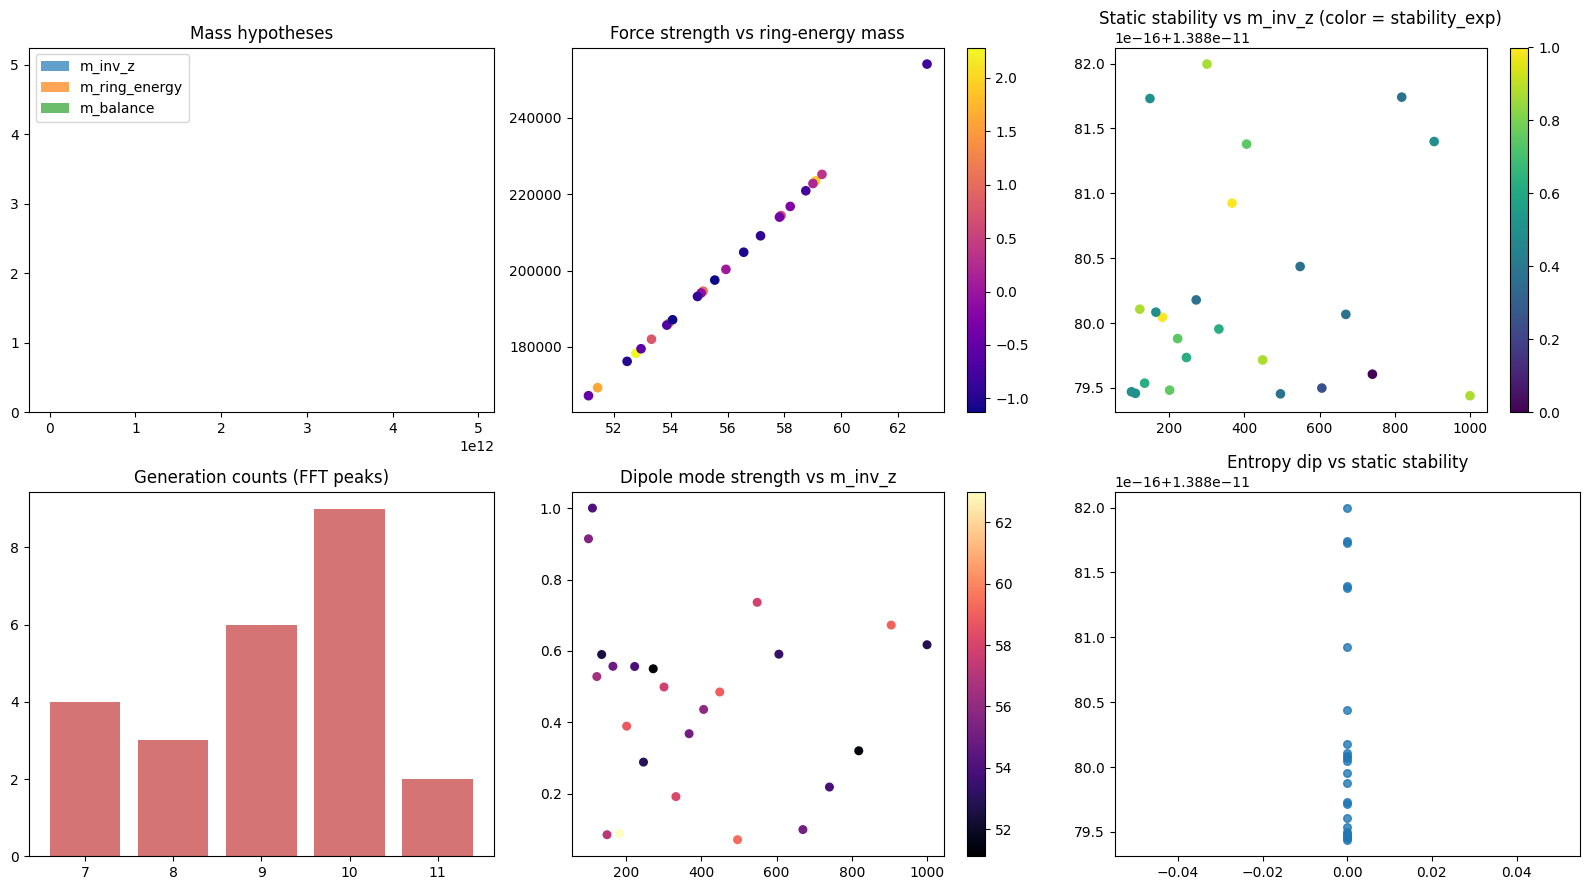

Correlation matrix (key pairs):
- m_inv_z vs stability_static: r = 0.147
- m_ring_energy vs stability_static: r = 0.104
- m_balance vs stability_static: r = 0.130
- stability_static vs stability_static: r = 1.000
- stability_exp vs stability_static: r = 0.130
- stability_logistic vs stability_static: r = 0.130
Generation clustering variance test: p = 0.8920
→ Consistent with uniform.
    z_depth  max_dip     stability  force_strength     m_inv_z  m_ring_energy  \
0  0.001000      0.0  1.388794e-11       52.781981  999.999999       178300.0   
1  0.001105      0.0  1.388814e-11       59.094733  904.735723       223500.0   
2  0.001222      0.0  1.388817e-11       51.432602  818.546730       169300.0   
3  0.001350      0.0  1.388796e-11       53.938623  740.568469       186200.0   
4  0.001492      0.0  1.388801e-11       55.141863  670.018750       194600.0   

      m_balance  stability_static  stability_exp  stability_logistic  \
0  4.932653e+12      1.388794e-11          0.875      

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.fft import fft
from scipy.signal import find_peaks
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score

# ==============================
# Config (4D static)
# ==============================

class Sim4DConfig:
    # Lattice (4D)
    n0 = 32
    n1 = 32
    n2 = 32
    n3 = 32

    # Static relaxation (iterations instead of time)
    relax_iters = 600
    measure_every = 50

    # Physics parameters (bounded to avoid blow-up)
    base_diffusion = 0.8     # α (scaled by 1/z^2)
    base_damping  = 0.12     # -damping*S
    base_mu_E     = 0.02     # quantum foam amplitude
    base_mem_rate = 0.02     # memory coupling strength

    # Couplings (bounded)
    gamma_plus  = 0.02       # M * (-S + ε)
    gamma_minus = 0.0125     # M * ( S + ε)

    # Relaxation blend
    blend = 0.35             # fraction of update applied each iteration

    # Slice and ring sampling (2D plane inside 4D lattice)
    ring_radius = 6
    ring_points = 64

class DecodeConfig:
    peak_prominence = 0.08
    histogram_bins = 40
    figsize = (16, 9)
    n_bootstraps = 500

# ==============================
# 4D operators and utilities
# ==============================

def laplacian_4d(field):
    lap = -8.0 * field
    for axis in range(4):
        lap += np.roll(field, 1, axis=axis) + np.roll(field, -1, axis=axis)
    return lap

def entropy_proxy(field):
    return float(np.var(field))

def clip_safe(x, limit=10.0):
    return np.clip(x, -limit, limit)

def exp_safe(x, clip_val=20.0):
    return np.exp(np.clip(x, -clip_val, clip_val))

def sample_ring_2d(field_2d, radius, n_points):
    n0, n1 = field_2d.shape
    c0, c1 = n0 // 2, n1 // 2
    theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    samples = []
    for t in theta:
        x = int(round(c0 + radius * np.cos(t))) % n0
        y = int(round(c1 + radius * np.sin(t))) % n1
        samples.append(field_2d[x, y])
    return np.asarray(samples, dtype=float)

# ==============================
# Static equilibrium solve per z (no time)
# ==============================

def solve_static_4d(z, cfg: Sim4DConfig):
    """
    Solve a bounded, static equilibrium for S,M on a 4D lattice at scale z:
      0 ≈ (α/z^2) ∇^2 S - damping*S + μ_E*ξ - γ_minus*M*(S+ε) + γ_plus*M*(-S+ε)
      M ≈ f(curvature, S) (algebraic, not ODE)

    We perform fixed-point relaxation:
      S_{k+1} = S_k + blend * RHS(S_k, M_k)
      M_{k+1} = (1 - λ) M_k + blend * G(S_k, ∇^2 S_k)
    """
    eps = 1e-9
    rng = np.random.default_rng(int(np.round(z * 1e9)) % (2**31-1))

    shape = (cfg.n0, cfg.n1, cfg.n2, cfg.n3)
    # P0: small noise, zero memory
    S = rng.normal(0.0, 1e-8, size=shape)
    M = np.zeros_like(S)

    alpha = cfg.base_diffusion
    damping = cfg.base_damping
    mu_E = cfg.base_mu_E
    gamma_plus = cfg.gamma_plus
    gamma_minus= cfg.gamma_minus
    mem_rate   = cfg.base_mem_rate

    # UV warp capped
    alpha_eff = alpha / (z**2 + eps)
    alpha_eff = min(alpha_eff, 5.0)

    ent_series = []

    for it in range(cfg.relax_iters):
        lap4 = laplacian_4d(S)
        lap4 = clip_safe(lap4, 50.0)

        # Algebraic memory "growth" from curvature with bounded exponential
        curv_mag = clip_safe(np.abs(lap4), 50.0)
        M_target = mem_rate * curv_mag * exp_safe(-20.0 * (S + eps), clip_val=15.0)
        # Leaky blend
        M = clip_safe(0.97 * M + cfg.blend * M_target, 5.0)

        # Noise per-iteration (static foam)
        xi = rng.normal(0.0, 1.0, size=shape)

        # RHS for S (bounded couplings)
        S_safe = clip_safe(S, 3.0)
        M_safe = clip_safe(M, 3.0)
        RHS = (
            alpha_eff * lap4
            - damping * S_safe
            + mu_E * xi
            - gamma_minus * M_safe * (S_safe + eps)
            + gamma_plus  * M_safe * (-S_safe + eps)
        )

        # Relaxation update
        S = clip_safe(S + cfg.blend * RHS, 5.0)

        if it % cfg.measure_every == 0:
            ent_series.append(entropy_proxy(S))

        # Safety
        if not np.all(np.isfinite(S)) or not np.all(np.isfinite(M)):
            print(f"Warning: NaN/Inf at iter {it}, z={z:.6f}")
            break

    # Static "dip": entropy reduction between early and late iterations
    S_initial = ent_series[0] if ent_series else entropy_proxy(S)
    S_final   = ent_series[-1] if ent_series else entropy_proxy(S)
    S_dip     = max(0.0, S_initial - S_final)

    # Static stability score: negative of final entropy (lower entropy → higher stability), normalized
    stab_raw = S_final
    stability_score = np.exp(-stab_raw)  # bounded, monotone

    # Extract 2D plane for ring sampling (fix last two axes at midpoints)
    phi_plane  = S[:, :, cfg.n2//2, cfg.n3//2]
    curv_plane = laplacian_4d(S)[:, :, cfg.n2//2, cfg.n3//2]  # reuse operator on full S

    curv_ring  = sample_ring_2d(curv_plane, cfg.ring_radius, cfg.ring_points)
    ent_ring   = sample_ring_2d(phi_plane,  cfg.ring_radius, cfg.ring_points)

    # Memory amplitude at central patch on plane
    c0, c1 = cfg.n0 // 2, cfg.n1 // 2
    k = 3
    M_plane = M[:, :, cfg.n2//2, cfg.n3//2]
    M_patch = M_plane[c0-k:c0+k+1, c1-k:c1+k+1]
    M_amp   = float(np.mean(M_patch))

    return {
        'S_dip': float(S_dip),
        'stability': float(stability_score),
        'curvature_ring': np.asarray(curv_ring, dtype=float),
        'entropy_ring': np.asarray(ent_ring, dtype=float),
        'M_amp': float(M_amp),
    }

# ==============================
# Sweep → DataFrame (no lifetime)
# ==============================

def run_4d_static_sweep(z_min=1e-3, z_max=1e-2, n_points=20, cfg: Sim4DConfig = Sim4DConfig()):
    z_values = np.logspace(np.log10(z_min), np.log10(z_max), n_points)
    rows = []
    for z in z_values:
        obs = solve_static_4d(z, cfg)
        rows.append({
            'z_depth': float(z),
            'max_dip': obs['S_dip'],
            'stability': obs['stability'],
            'curvature_ring': obs['curvature_ring'],
            'entropy_ring': obs['entropy_ring'],
            'memory_amp': obs['M_amp'],
        })
    return pd.DataFrame(rows)

# ==============================
# Hypothesis-first decoding (adapted: no lifetime)
# ==============================

def add_force_strength(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    def ring_rms(r):
        r = np.asarray(r, dtype=float)
        return float(np.sqrt(np.mean(r**2)))
    out['force_strength'] = out['curvature_ring'].apply(ring_rms)
    return out

def add_mass_hypotheses(df: pd.DataFrame, mass_unit: float = 1.0) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-12
    out['m_inv_z'] = mass_unit / (out['z_depth'] + eps)
    def ring_energy(r):
        r = np.asarray(r, dtype=float)
        return float(np.sum(r**2))
    out['m_ring_energy'] = out['curvature_ring'].apply(ring_energy)
    out['m_balance'] = out['memory_amp'] / (out['max_dip'] + eps)
    for col in ['m_inv_z','m_ring_energy','m_balance']:
        x = out[col].values
        out[col + '_zscore'] = (x - np.mean(x)) / (np.std(x) + eps)
    return out

def add_stability_metrics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-12
    s, m = out['max_dip'], out['memory_amp']
    s_norm = (s - s.min()) / (s.max() - s.min() + eps)
    m_norm = (m - m.min()) / (m.max() - m.min() + eps)
    # Use the static stability from the solver as one metric, and two descriptive forms
    out['stability_static']   = out['stability']
    out['stability_exp']      = m_norm * np.exp(-s_norm)
    out['stability_logistic'] = m_norm / (1.0 + np.exp(5.0 * (s_norm - 0.5)))
    return out

def add_ring_metrics(df: pd.DataFrame, peak_prominence: float = 0.08) -> pd.DataFrame:
    out = df.copy()
    gen_counts, peak_lists = [], []
    for _, row in out.iterrows():
        ring = np.asarray(row['curvature_ring'], dtype=float)
        spec = np.abs(fft(ring - ring.mean()))[:ring.size // 2]
        spec_norm = spec / (spec.max() + 1e-12)
        peaks, _ = find_peaks(spec_norm, prominence=peak_prominence)
        gen_counts.append(len(peaks))
        peak_lists.append(peaks.tolist())
    out['generation_count'] = gen_counts
    out['ring_peak_indices'] = peak_lists
    return out

def add_dipole_mode(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dip = []
    for _, row in out.iterrows():
        er = row.get('entropy_ring', None)
        if er is None:
            dip.append(np.nan); continue
        arr = np.asarray(er, dtype=float)
        spec = np.abs(fft(arr - arr.mean()))
        dip.append(spec[1] / (spec.max() + 1e-12))
    out['dipole_mode_strength'] = dip
    return out

# ==============================
# Atlas (no lifetime panels)
# ==============================

def atlas_static(df: pd.DataFrame, bins: int = 40, figsize=(16,9)):
    fig, axs = plt.subplots(2, 3, figsize=figsize)

    # Mass hypotheses
    axs[0,0].hist(df['m_inv_z'], bins=bins, alpha=0.7, label='m_inv_z')
    axs[0,0].hist(df['m_ring_energy'], bins=bins, alpha=0.7, label='m_ring_energy')
    axs[0,0].hist(df['m_balance'], bins=bins, alpha=0.7, label='m_balance')
    axs[0,0].set_title('Mass hypotheses'); axs[0,0].legend()

    # Force strength vs ring-energy mass
    sc1 = axs[0,1].scatter(df['force_strength'], df['m_ring_energy'], c=df['m_inv_z_zscore'], cmap='plasma', s=35)
    axs[0,1].set_title('Force strength vs ring-energy mass'); plt.colorbar(sc1, ax=axs[0,1])

    # Stability metrics (static) vs m_inv_z
    sc2 = axs[0,2].scatter(df['m_inv_z'], df['stability_static'], c=df['stability_exp'], cmap='viridis', s=35)
    axs[0,2].set_title('Static stability vs m_inv_z (color = stability_exp)'); plt.colorbar(sc2, ax=axs[0,2])

    # Generation counts
    counts = df['generation_count'].value_counts().sort_index()
    axs[1,0].bar(counts.index.astype(int), counts.values, color='indianred', alpha=0.85)
    axs[1,0].set_title('Generation counts (FFT peaks)')

    # Dipole mode vs m_inv_z
    sc3 = axs[1,1].scatter(df['m_inv_z'], df['dipole_mode_strength'], c=df['force_strength'], cmap='magma', s=30)
    axs[1,1].set_title('Dipole mode strength vs m_inv_z'); plt.colorbar(sc3, ax=axs[1,1])

    # Max dip vs static stability
    axs[1,2].scatter(df['max_dip'], df['stability_static'], s=30, alpha=0.8)
    axs[1,2].set_title('Entropy dip vs static stability')

    plt.tight_layout(); plt.show()

# ==============================
# Decoding orchestration
# ==============================

def decode_pipeline_static(success_df: pd.DataFrame, peak_prominence: float = 0.08, mass_unit: float = 1.0, show_plots: bool = True):
    out = success_df.copy()
    out = add_force_strength(out)
    out = add_mass_hypotheses(out, mass_unit=mass_unit)
    out = add_stability_metrics(out)
    out = add_ring_metrics(out, peak_prominence=peak_prominence)
    out = add_dipole_mode(out)
    if show_plots:
        atlas_static(out, bins=DecodeConfig.histogram_bins, figsize=DecodeConfig.figsize)
    return out

def correlation_report_static(df: pd.DataFrame):
    cols = ['m_inv_z','m_ring_energy','m_balance','stability_static','stability_exp','stability_logistic']
    print('Correlation matrix (key pairs):')
    for c in cols:
        r = np.corrcoef(df[c].values, df['stability_static'].values)[0,1]
        print(f'- {c} vs stability_static: r = {r:.3f}')

def test_generation_clustering(df: pd.DataFrame, n_bootstraps: int = 500):
    observed = df['generation_count'].values
    min_c, max_c = int(observed.min()), int(observed.max())
    obs_var = float(np.var(observed))
    rng = np.random.default_rng()
    null_vars = []
    for _ in range(n_bootstraps):
        null_sample = rng.integers(low=min_c, high=max_c+1, size=len(observed))
        null_vars.append(float(np.var(null_sample)))
    p_value = np.mean([nv >= obs_var for nv in null_vars])
    print(f'Generation clustering variance test: p = {p_value:.4f}')
    print('→ Significant clustering (reject uniform).' if p_value < 0.05 else '→ Consistent with uniform.')

# ==============================
# Entry point
# ==============================

if __name__ == "__main__":
    cfg = Sim4DConfig()
    # Small sweep
    df = run_4d_static_sweep(n_points=24, cfg=cfg)
    decoded = decode_pipeline_static(df, peak_prominence=DecodeConfig.peak_prominence, mass_unit=1.0, show_plots=True)

    correlation_report_static(decoded)
    test_generation_clustering(decoded)

    cols = ['z_depth','max_dip','stability','force_strength',
            'm_inv_z','m_ring_energy','m_balance',
            'stability_static','stability_exp','stability_logistic',
            'generation_count','dipole_mode_strength']
    print(decoded[cols].head())
